In [ ]:
# Install required libraries
!pip install ultralytics
!pip install roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 129.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


In [ ]:
# Import required libraries
from ultralytics import YOLO
from roboflow import Roboflow
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="XprIetE05kQWU8MWtzFC")
project = rf.workspace("saharsh-kumar-singh").project("axial-mri-l9kt1")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to axial-MRI-1 in yolov8:: 100%|██████████| 747/747 [00:00<00:00, 10462.30it/s]


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'axial-MRI-1', 'sample_data']


In [9]:
# Load pretrained YOLOv8 model
model = YOLO("yolov8n.pt")


In [10]:
# Train the model on the MRI dataset
results = model.train(
    data="/content/axial-MRI-1/data.yaml",
    epochs=10,
    imgsz=640,
    batch=8,
    project="runs",
    name="axial_mri_detection"
)

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/axial-MRI-1/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=axial_mri_detection-2, nbs=64, nms=False, opset=None, optimize=False, opt

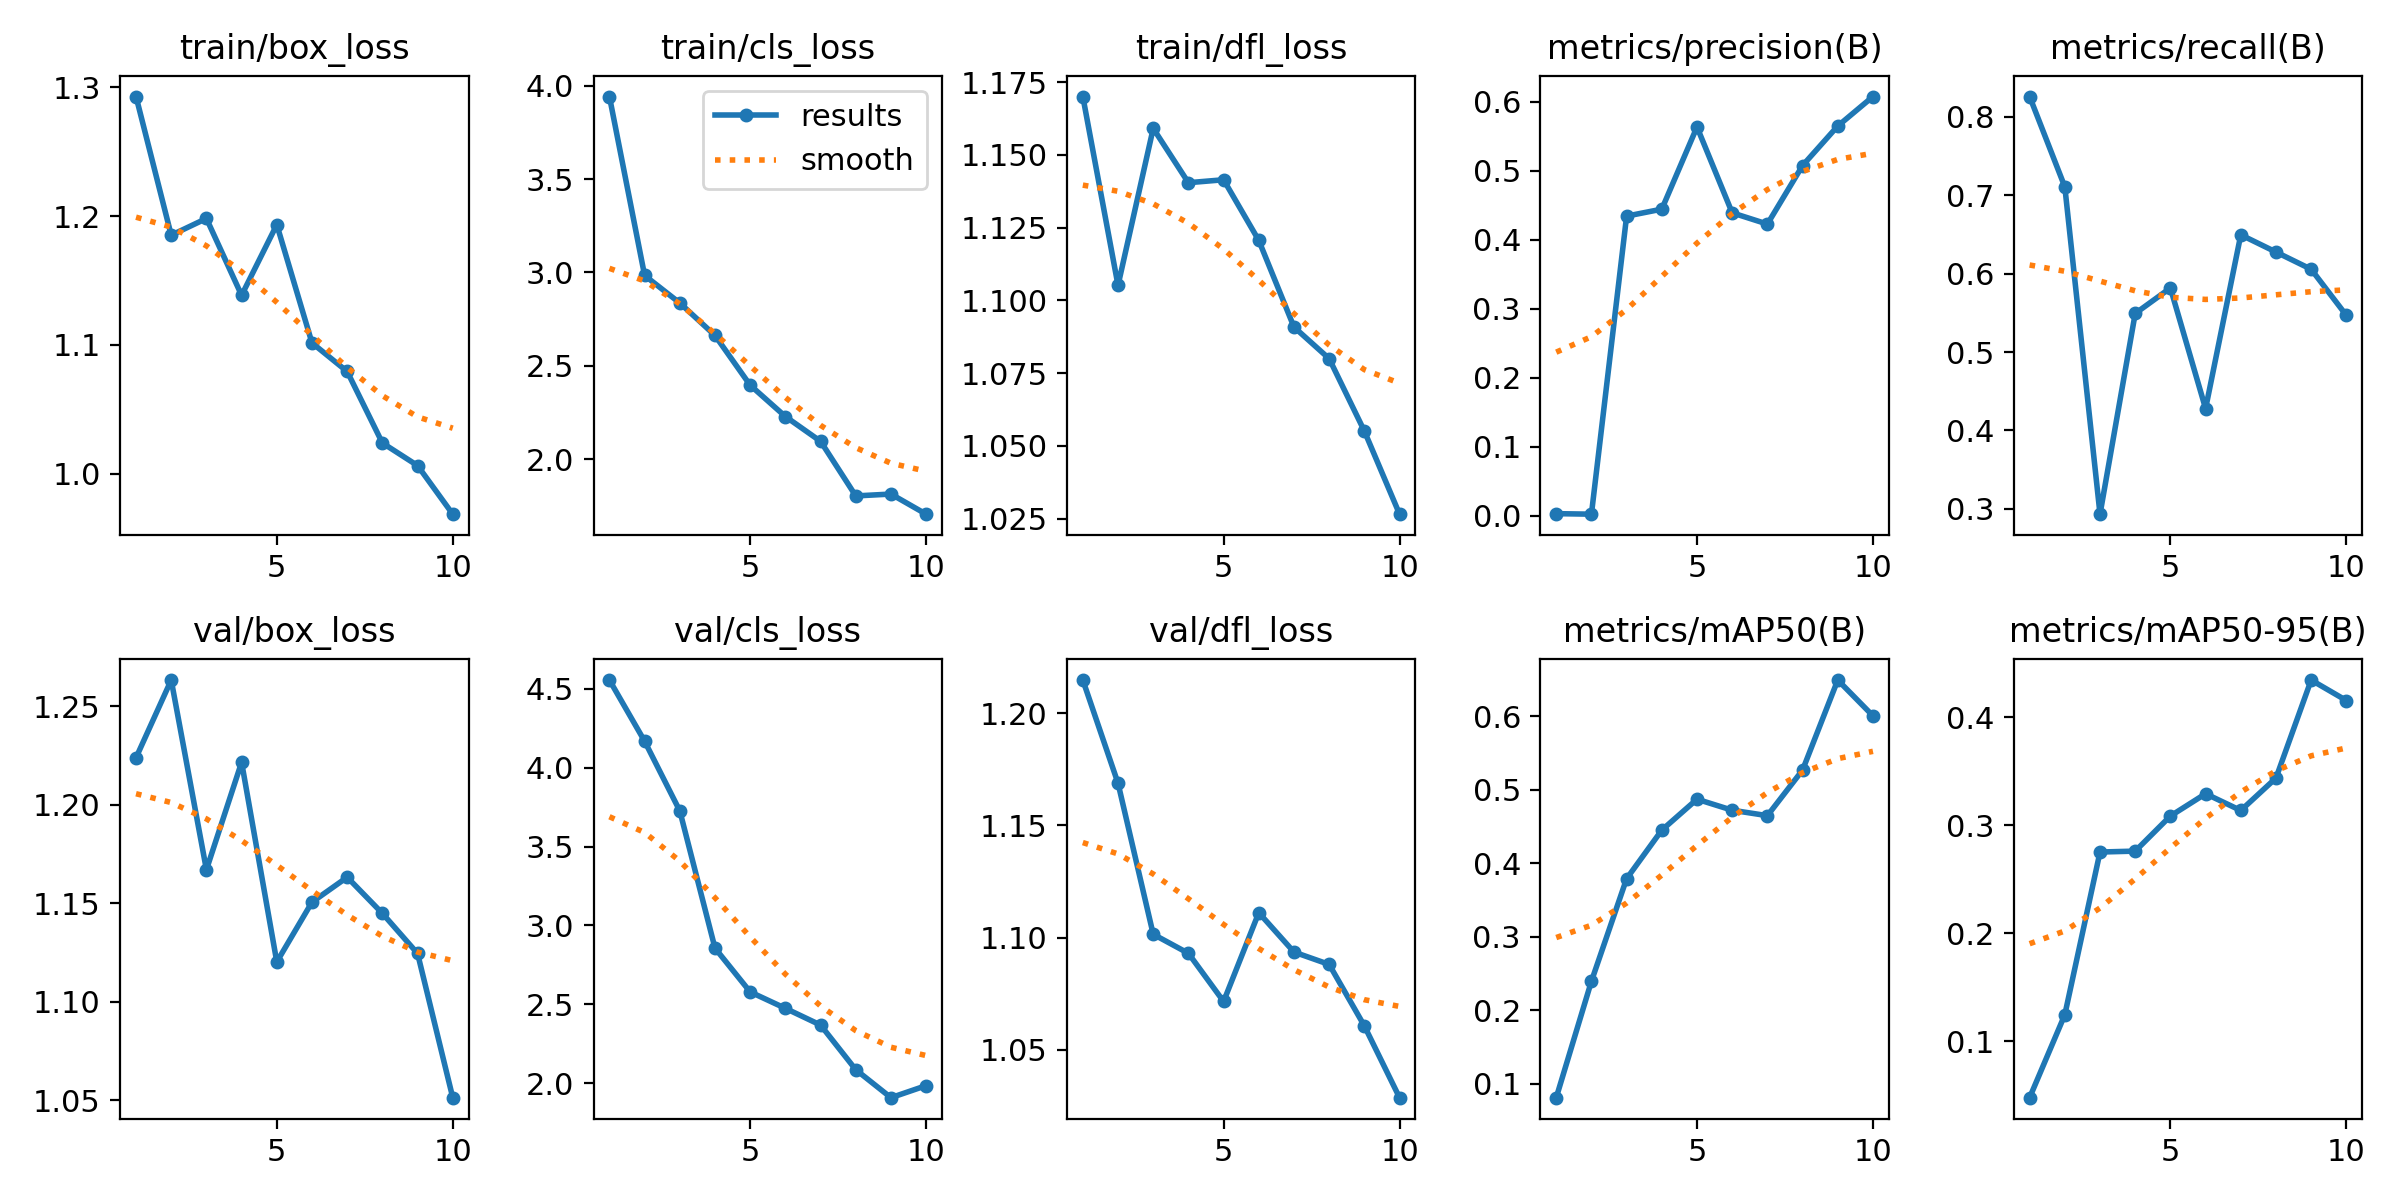

In [11]:
from IPython.display import Image

Image("/content/runs/detect/runs/axial_mri_detection-2/results.png", width=900)

In [12]:
# Load the best trained model
model = YOLO("/content/runs/detect/runs/axial_mri_detection-2/weights/best.pt")

In [13]:
# Predict on MRI test images
model.predict(
    source="/content/axial-MRI-1/test/images",
    save=True,
    conf=0.25
)


image 1/39 /content/axial-MRI-1/test/images/00306_109_jpg.rf.db365a08dcf047bf21060f91ae45dcde.jpg: 640x640 1 negative, 564.9ms
image 2/39 /content/axial-MRI-1/test/images/00306_115_jpg.rf.ea0413793904559b35b67c5d2882aa63.jpg: 640x640 1 negative, 221.7ms
image 3/39 /content/axial-MRI-1/test/images/00306_92_jpg.rf.b17254628e72f2d2032bec272c790fb1.jpg: 640x640 1 negative, 194.4ms
image 4/39 /content/axial-MRI-1/test/images/00306_96_jpg.rf.08deb6b9556dd334d9c9b9a6d02fdbc5.jpg: 640x640 1 negative, 191.3ms
image 5/39 /content/axial-MRI-1/test/images/00311_105_jpg.rf.fc92a04fee14d79cddd3134b434de548.jpg: 640x640 1 positive, 192.5ms
image 6/39 /content/axial-MRI-1/test/images/00311_111_jpg.rf.37041ba23d173ec753f3018422a09a10.jpg: 640x640 1 positive, 192.1ms
image 7/39 /content/axial-MRI-1/test/images/00311_117_jpg.rf.e40a95275ae84f3ecc178094ae739687.jpg: 640x640 1 positive, 195.5ms
image 8/39 /content/axial-MRI-1/test/images/00311_118_jpg.rf.4575b0e97a46efa8f42fd3c0e3afcfb0.jpg: 640x640 1 pos

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'negative', 1: 'positive'}
 obb: None
 orig_img: array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        ...,
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
      

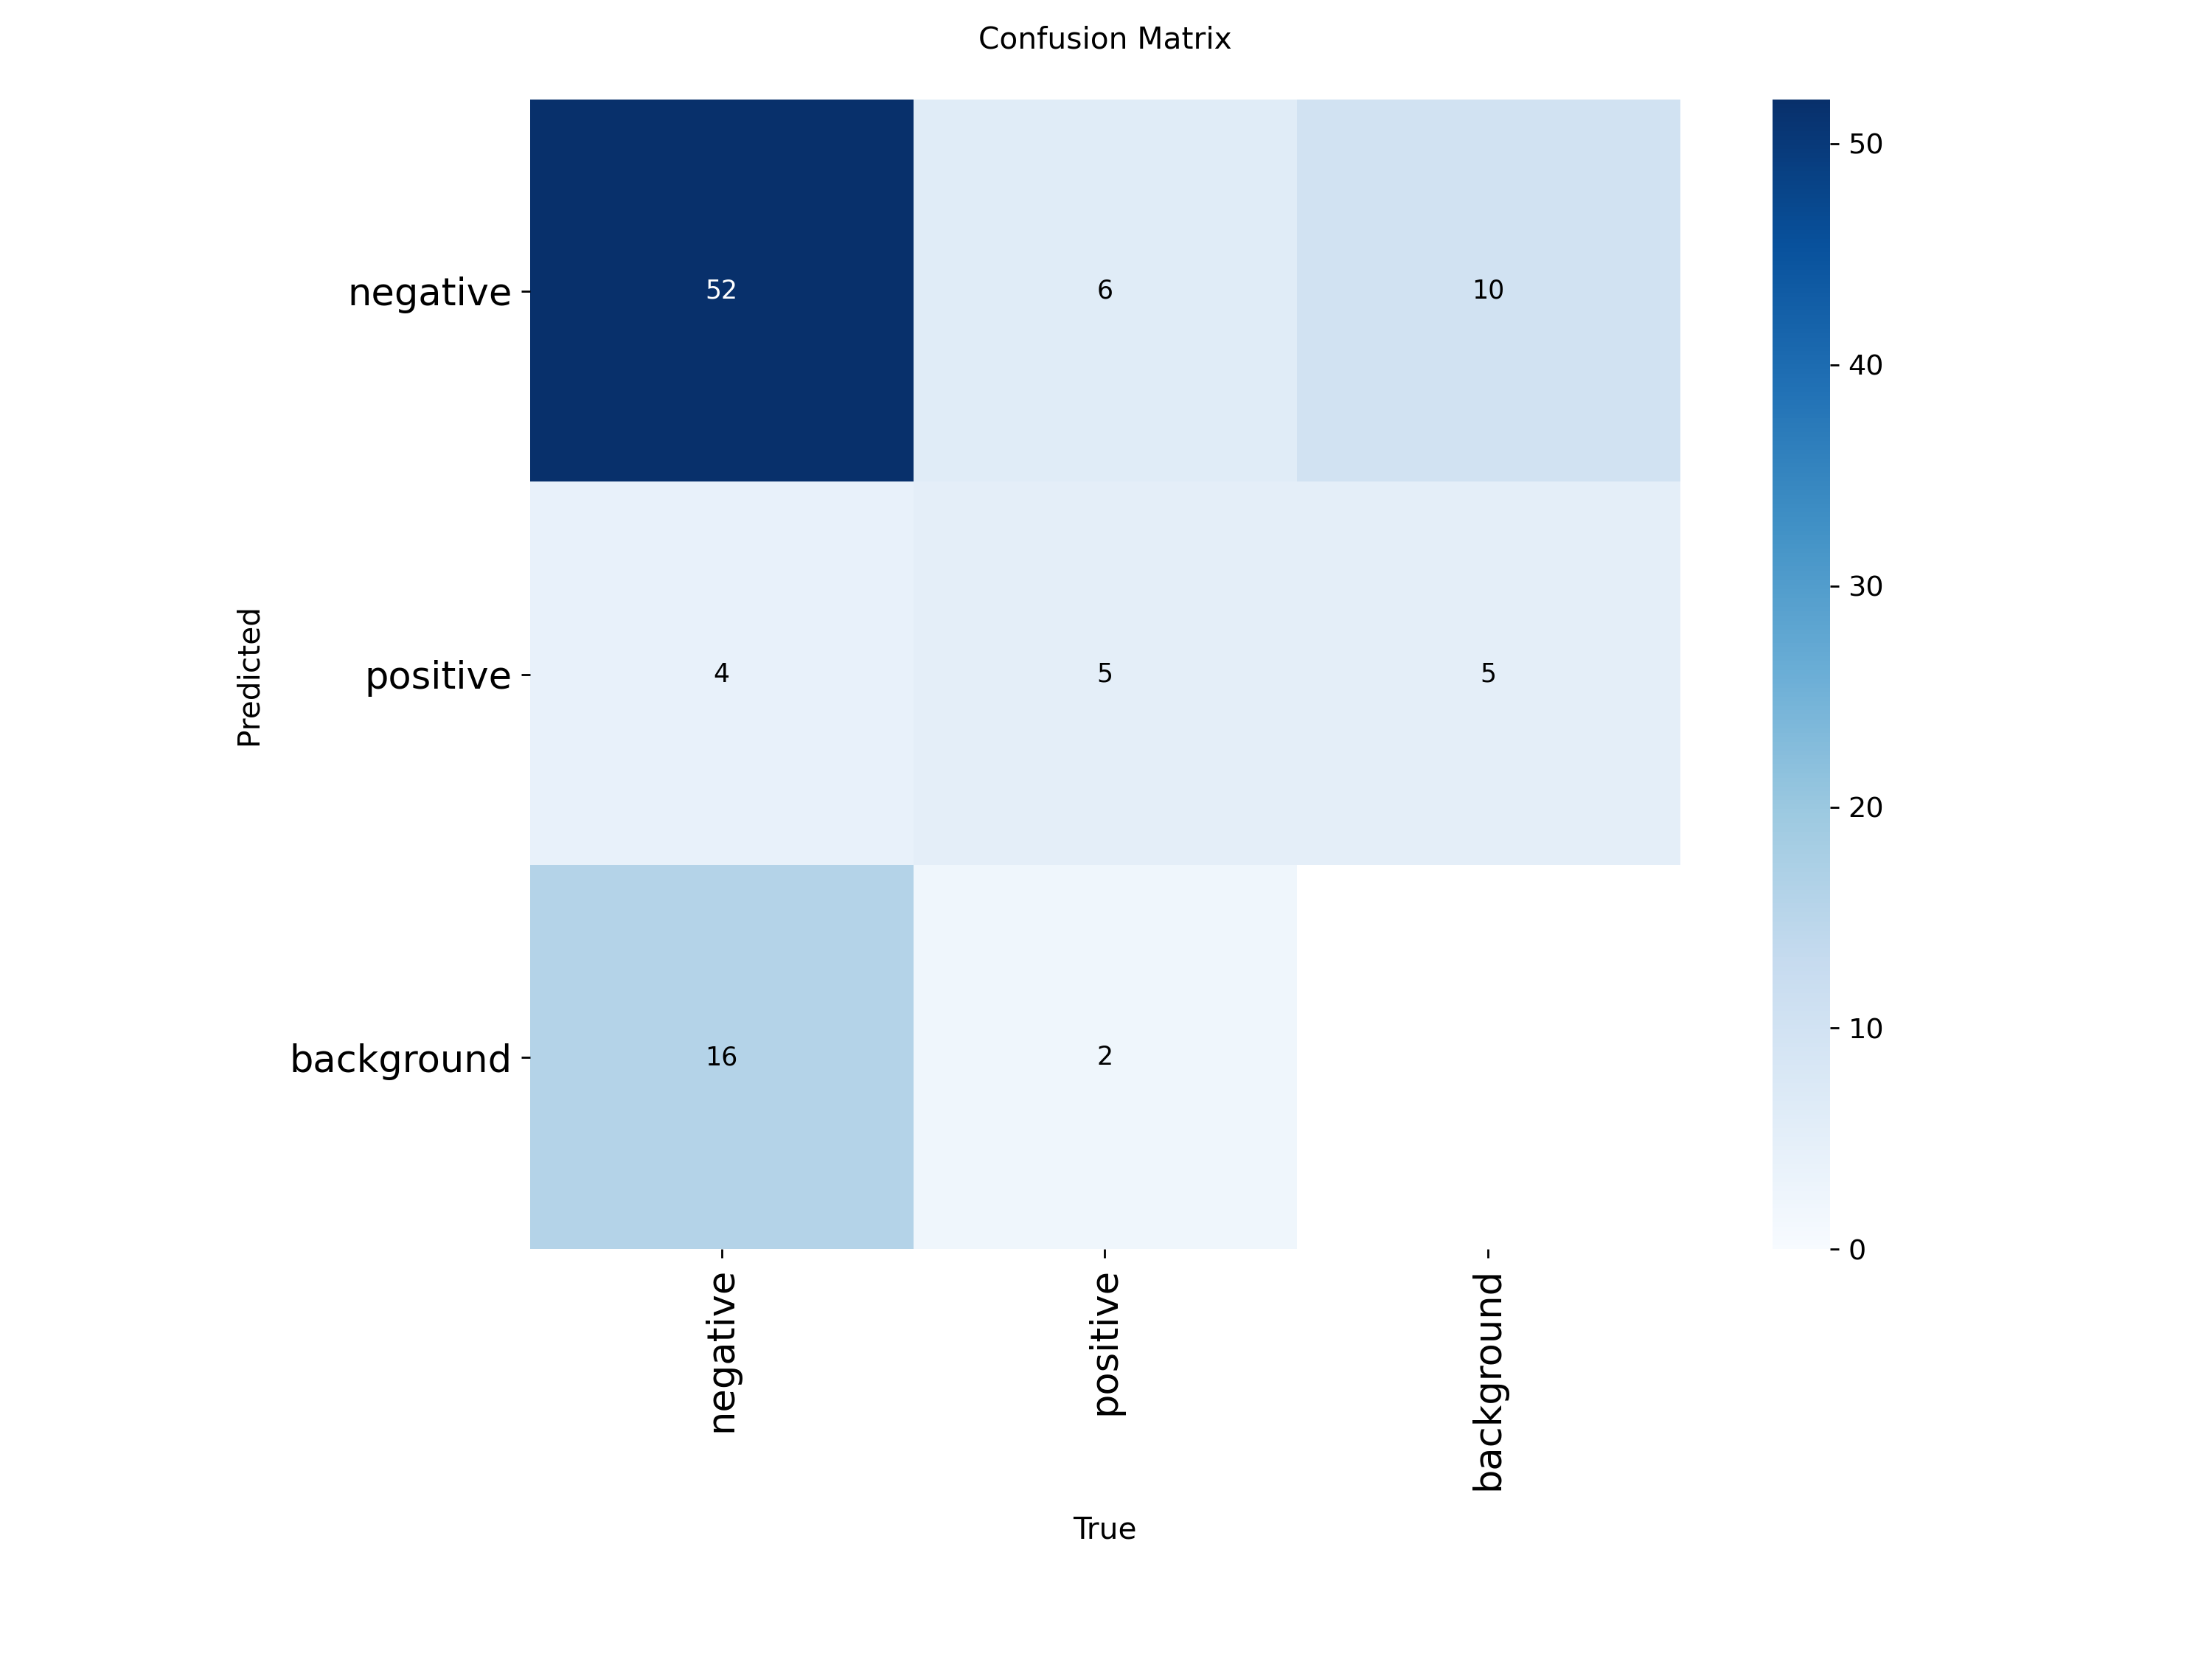

In [14]:
Image("/content/runs/detect/runs/axial_mri_detection-2/confusion_matrix.png", width=600)


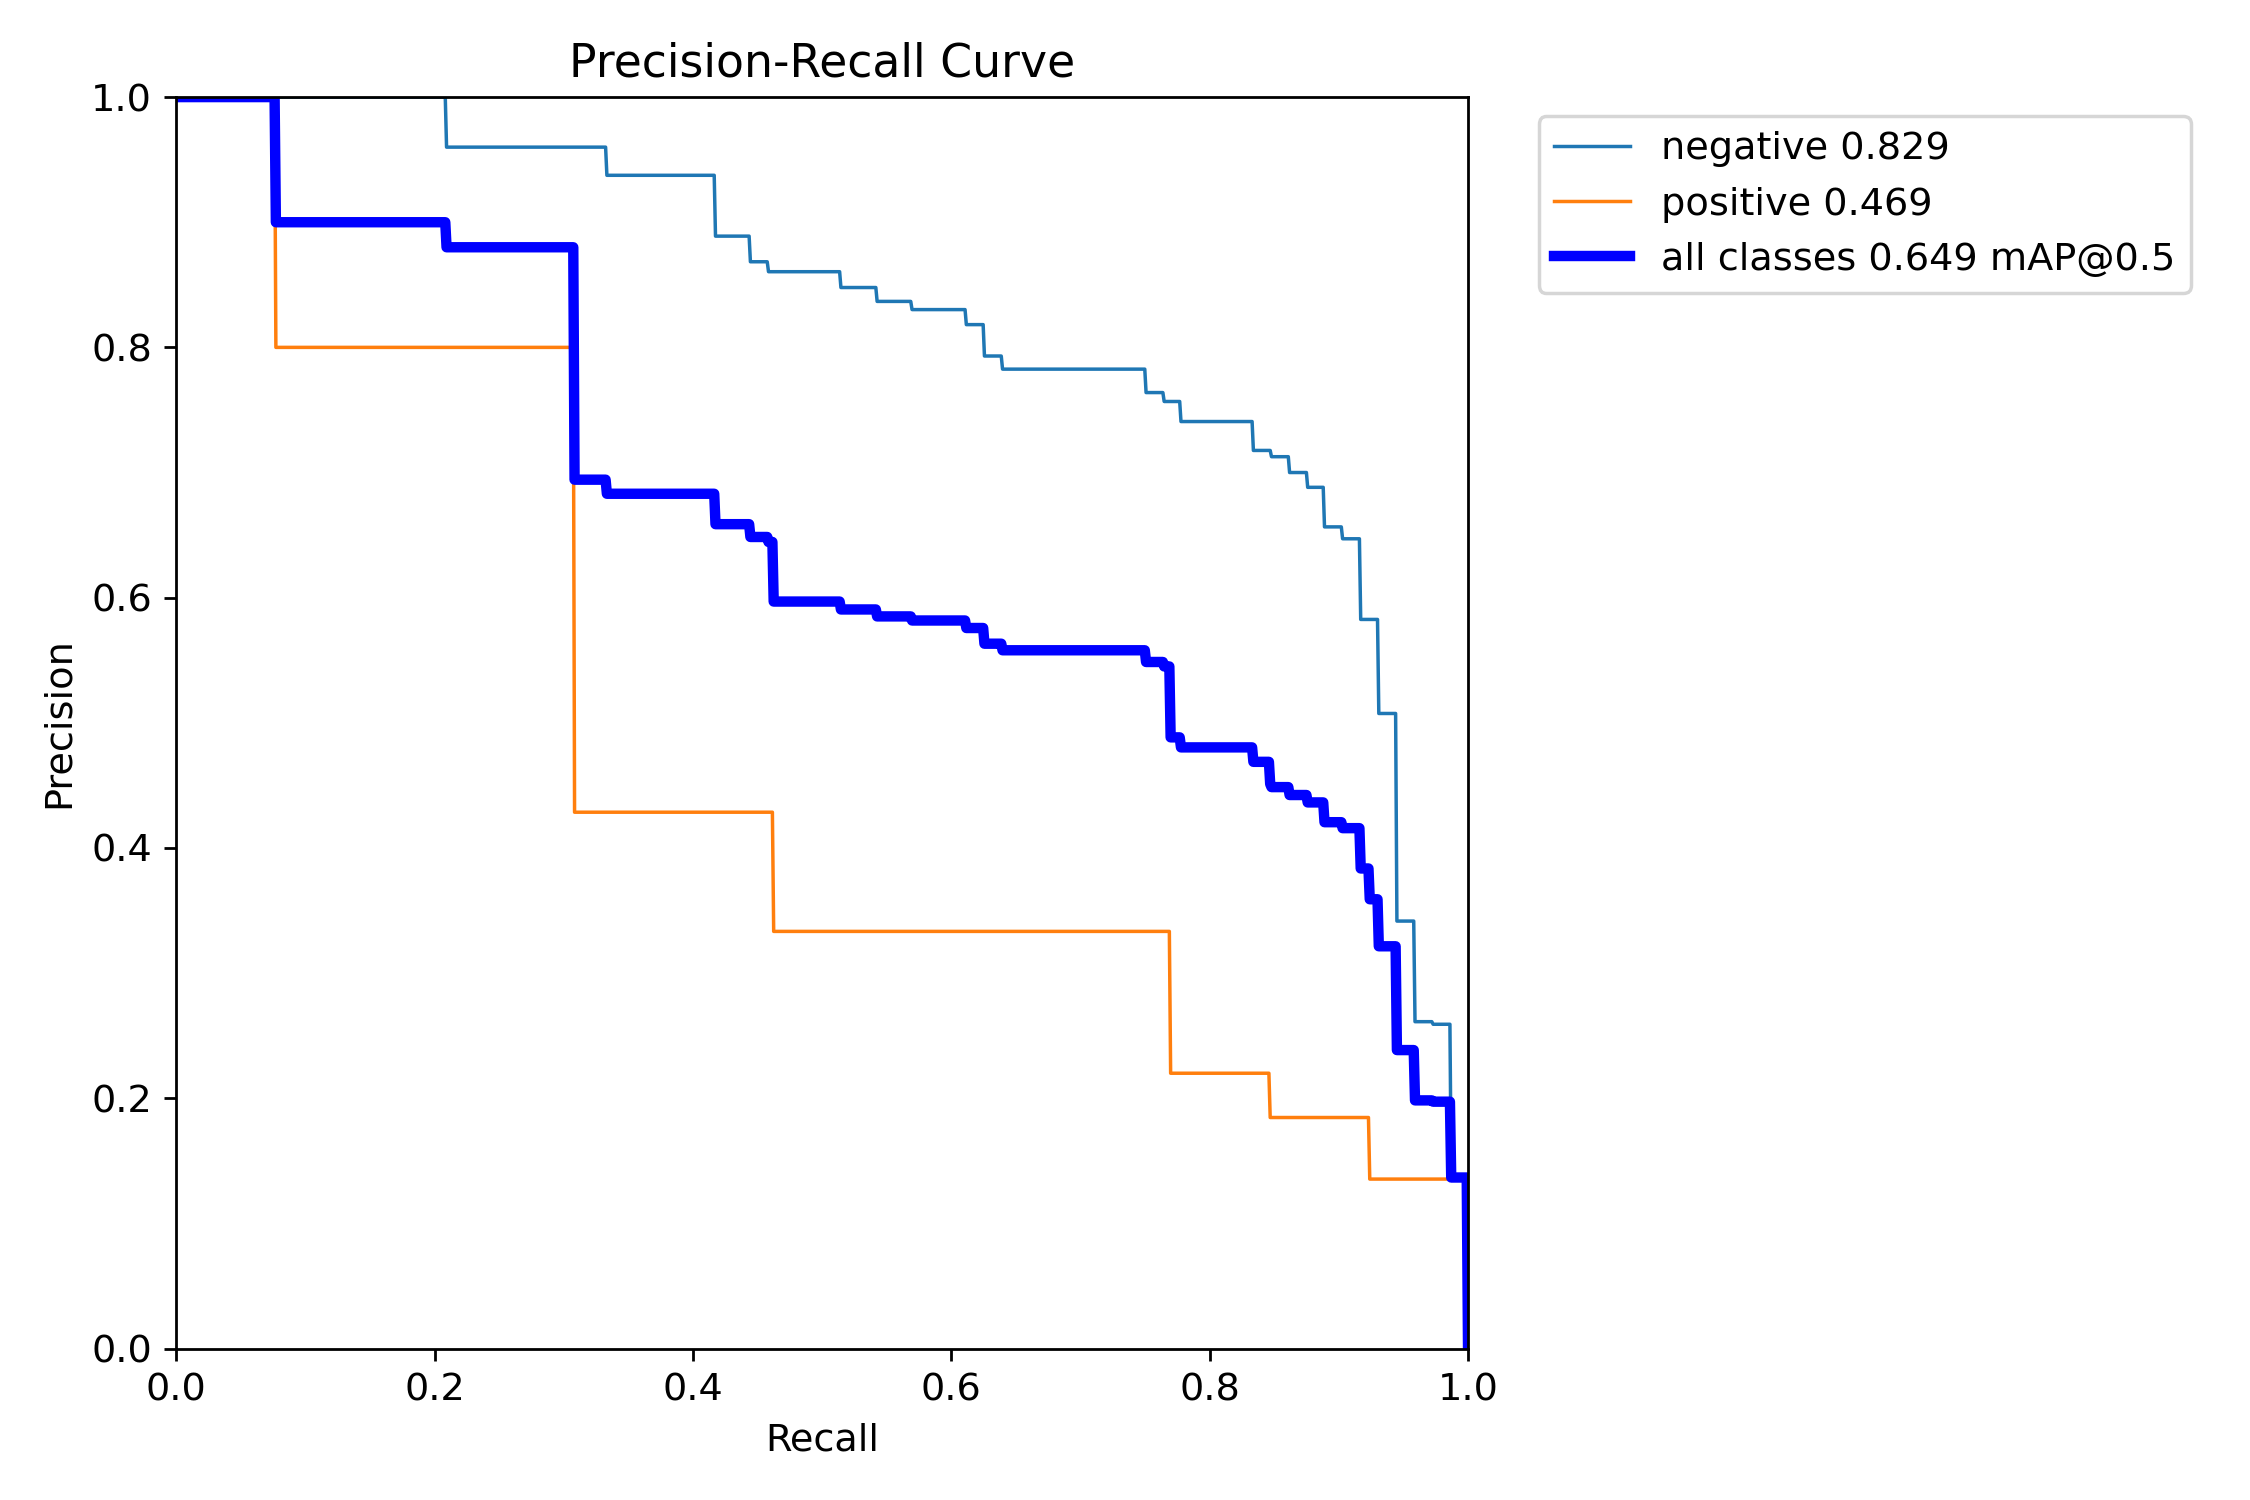

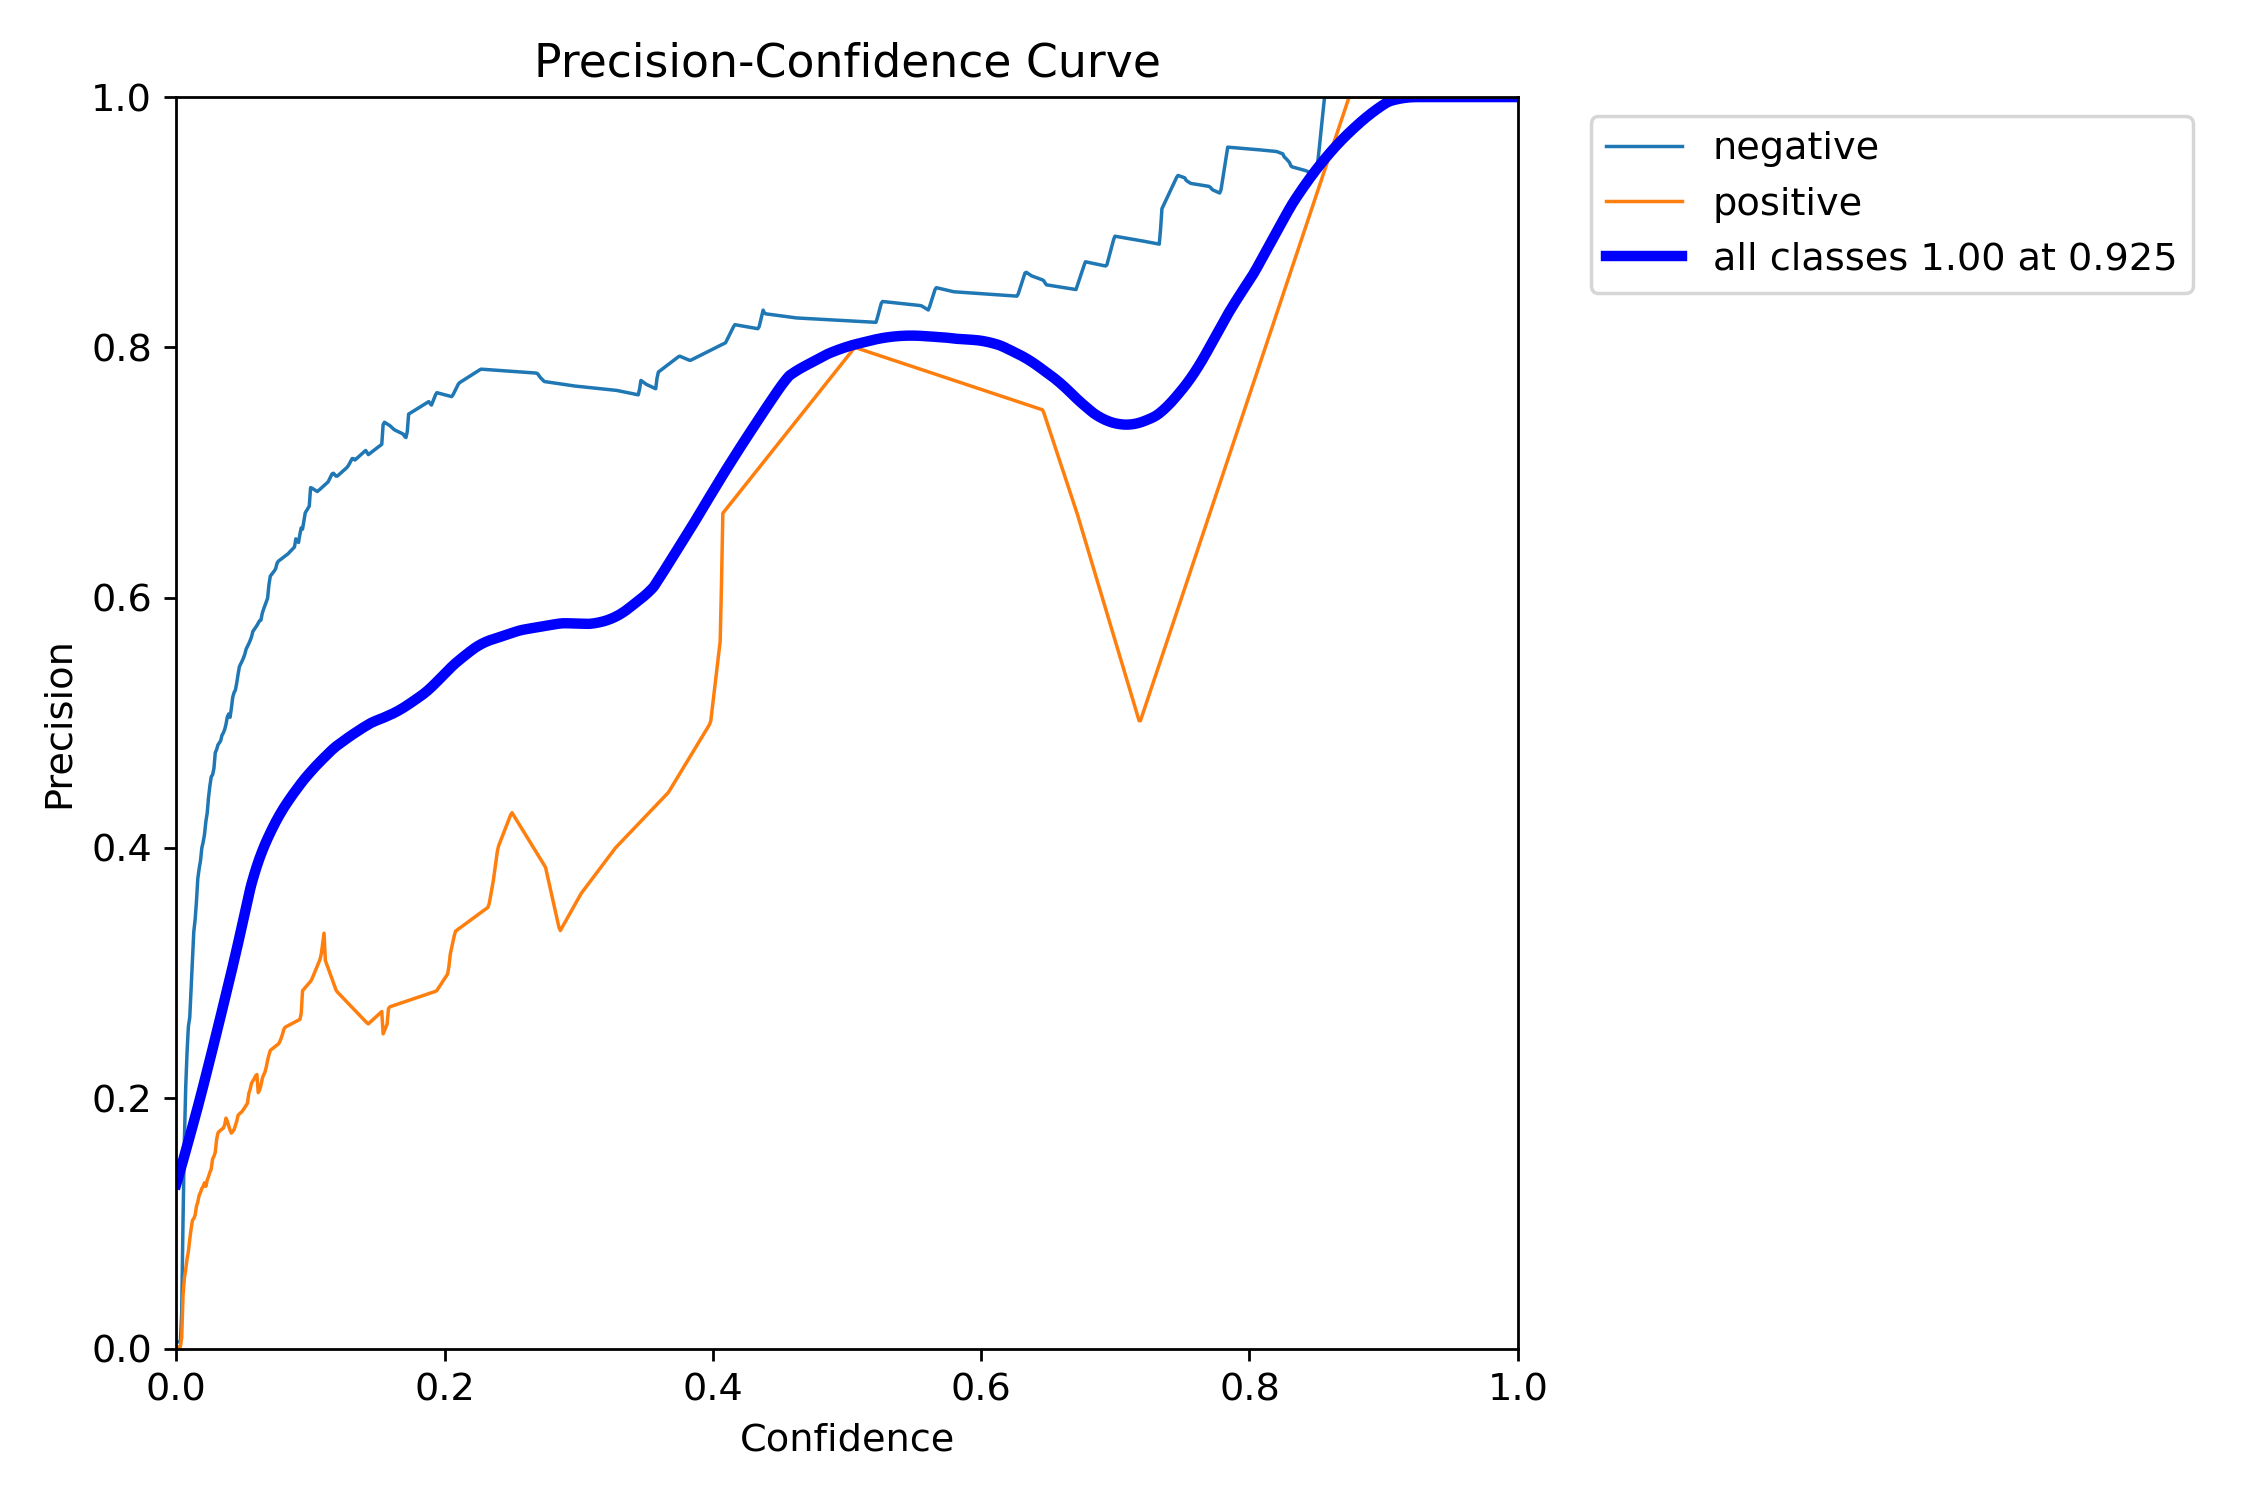

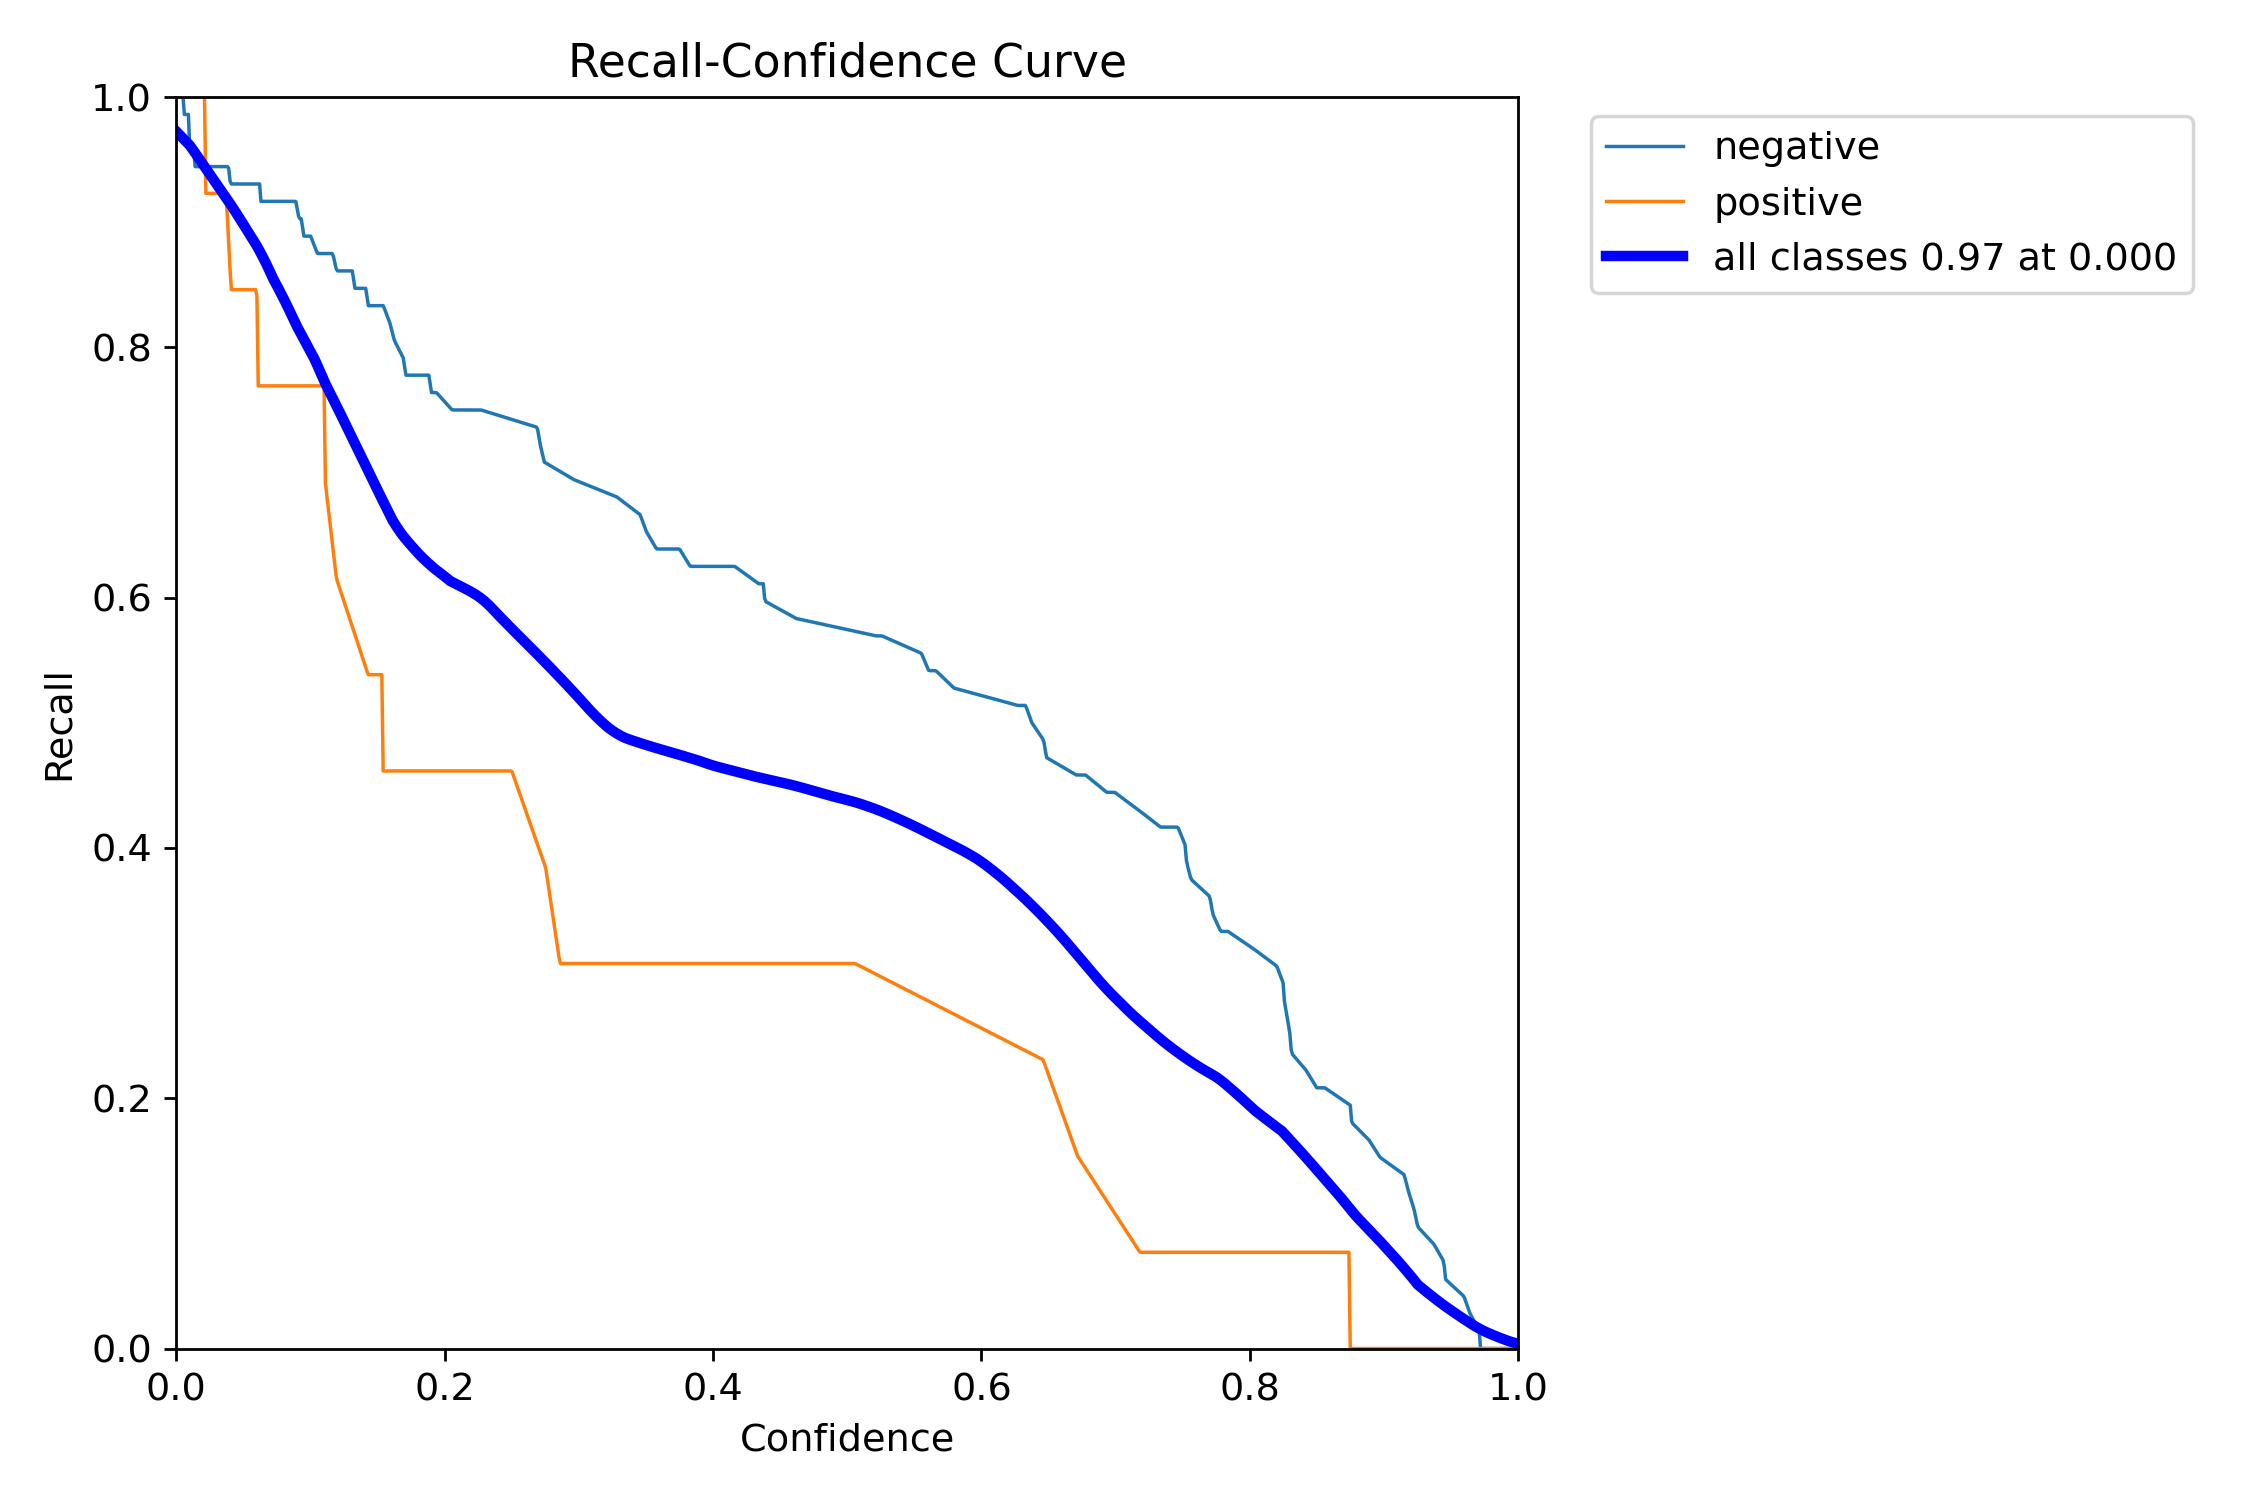

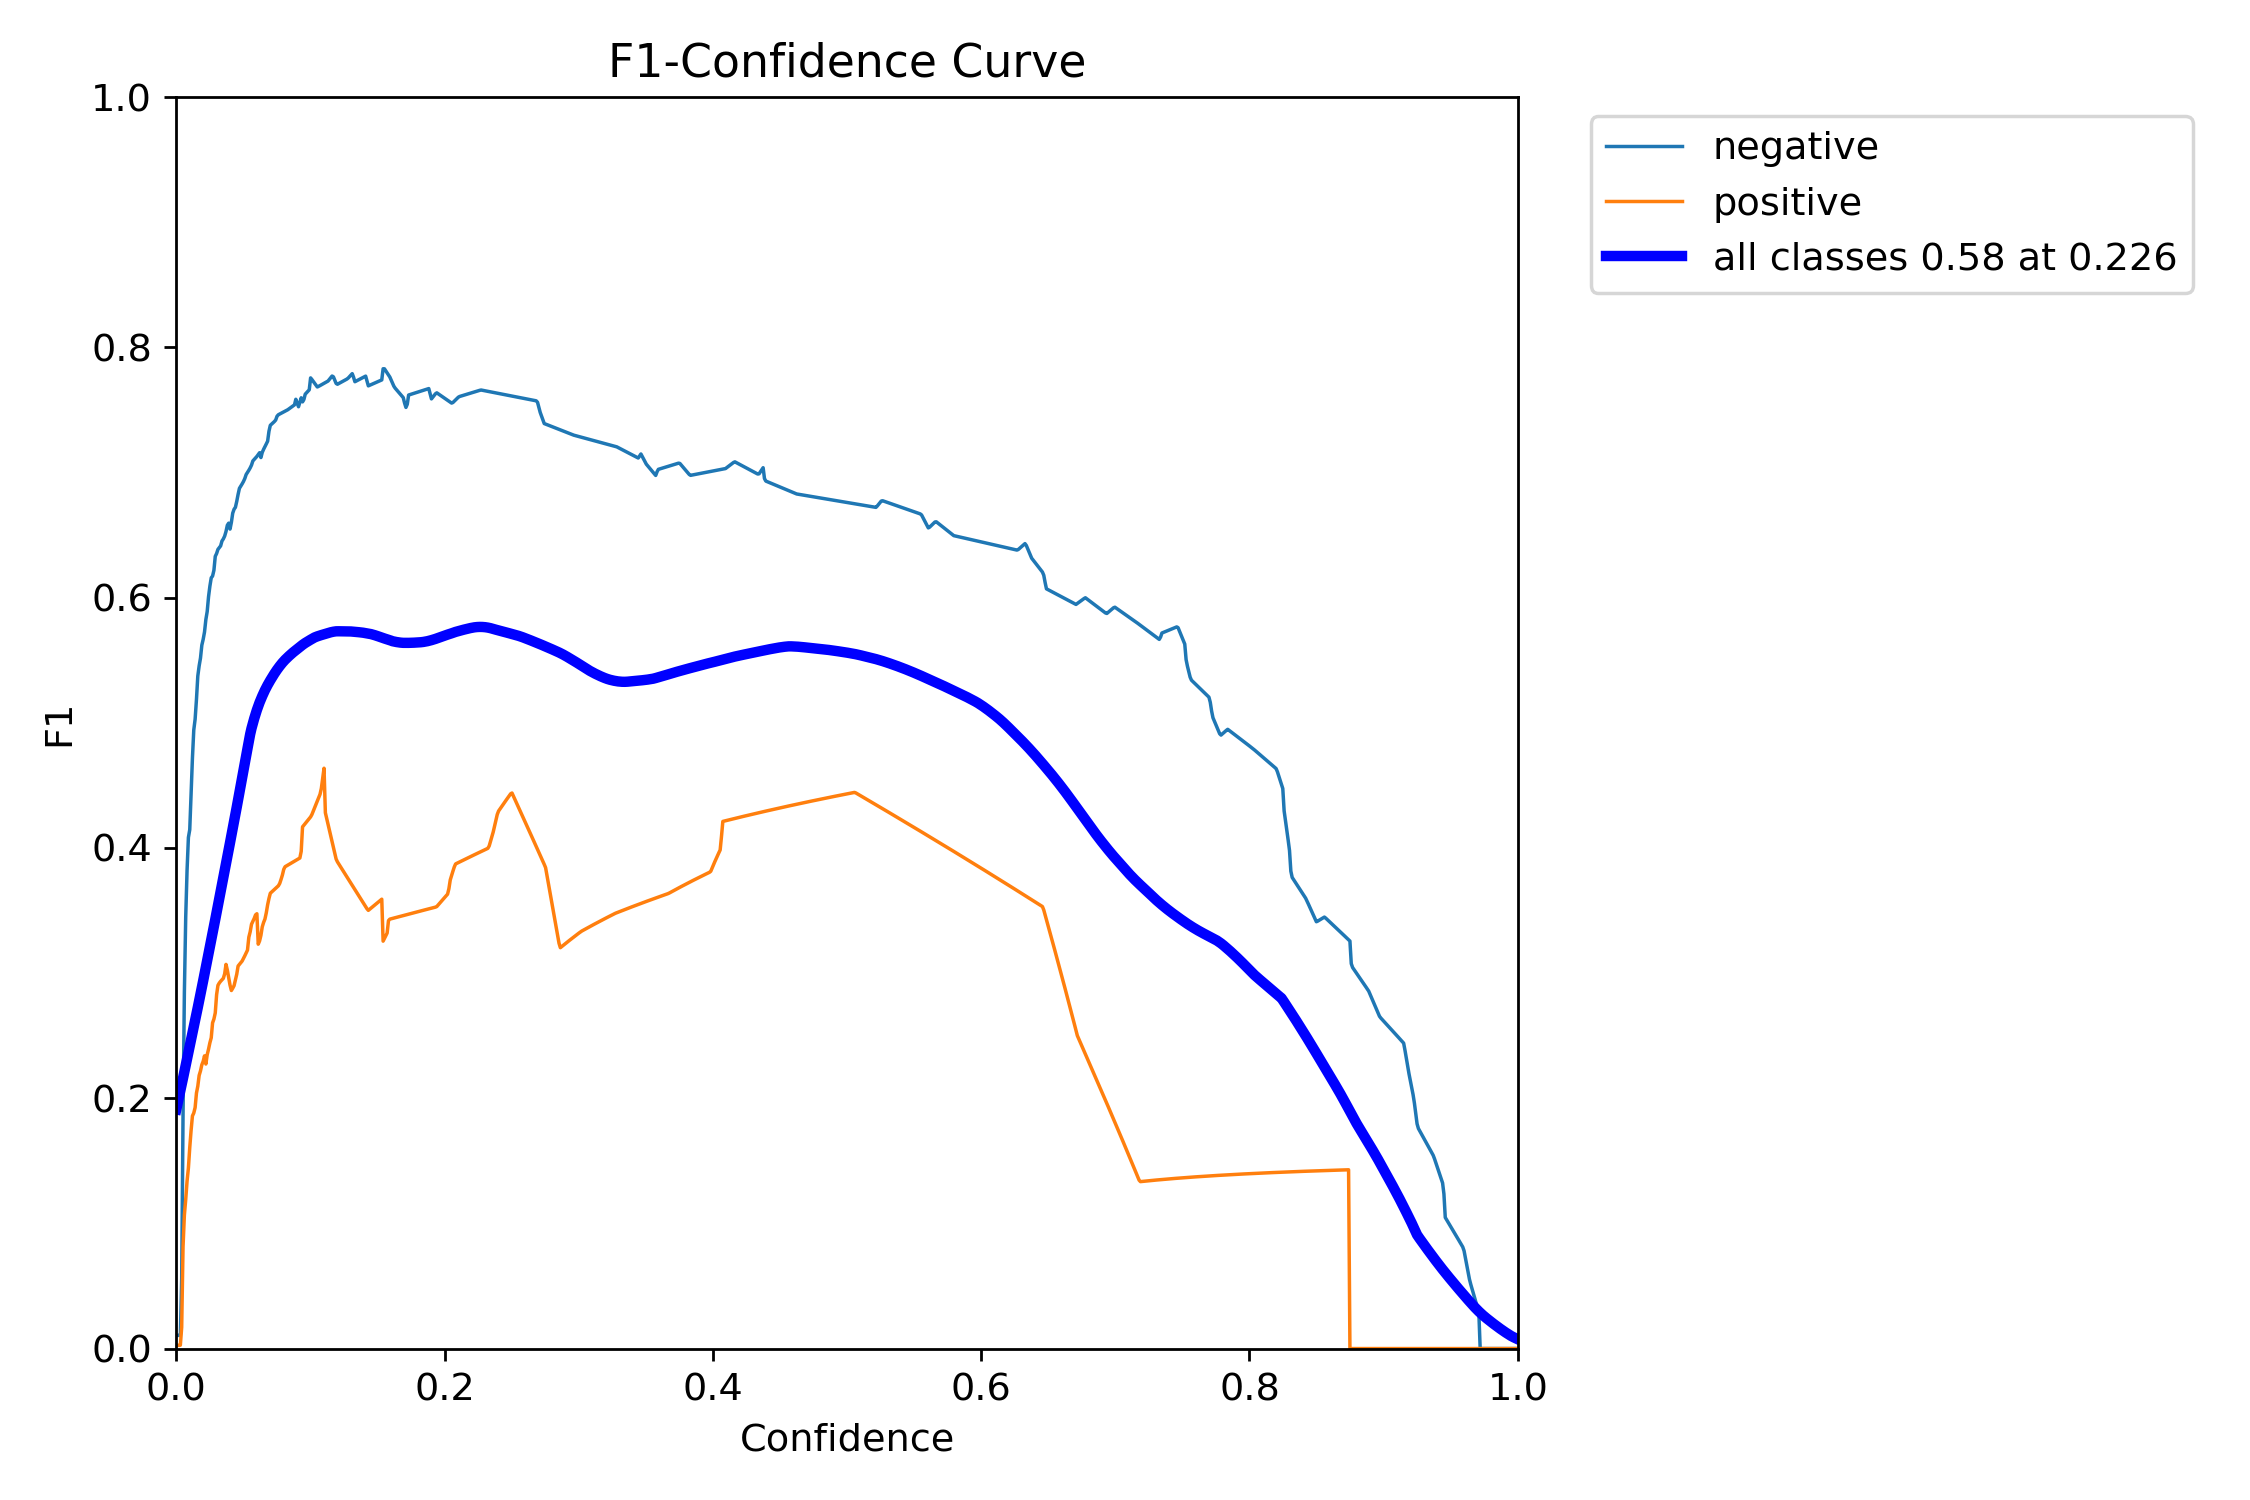

In [15]:
# Evaluation Curves

from IPython.display import Image, display

display(Image("/content/runs/detect/runs/axial_mri_detection-2/BoxPR_curve.png", width=600))
display(Image("/content/runs/detect/runs/axial_mri_detection-2/BoxP_curve.png", width=600))
display(Image("/content/runs/detect/runs/axial_mri_detection-2/BoxR_curve.png", width=600))
display(Image("/content/runs/detect/runs/axial_mri_detection-2/BoxF1_curve.png", width=600))

In [16]:
import os

print(os.listdir("/content/runs/detect"))

['runs', 'predict']


Found 39 predicted images.



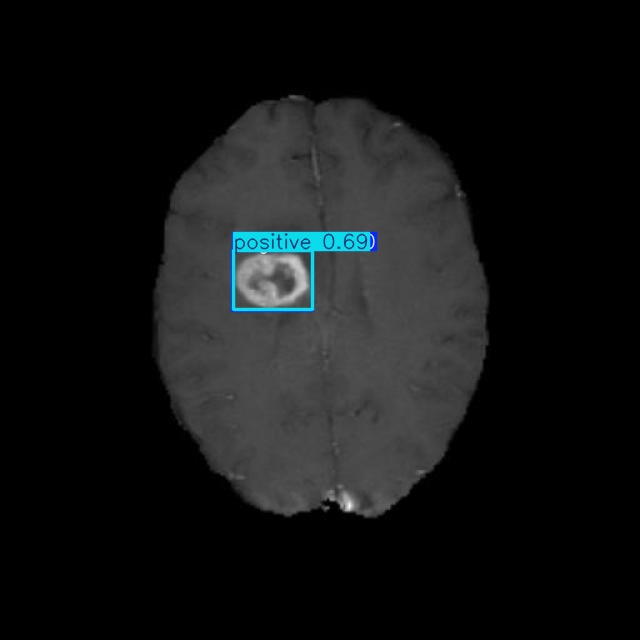

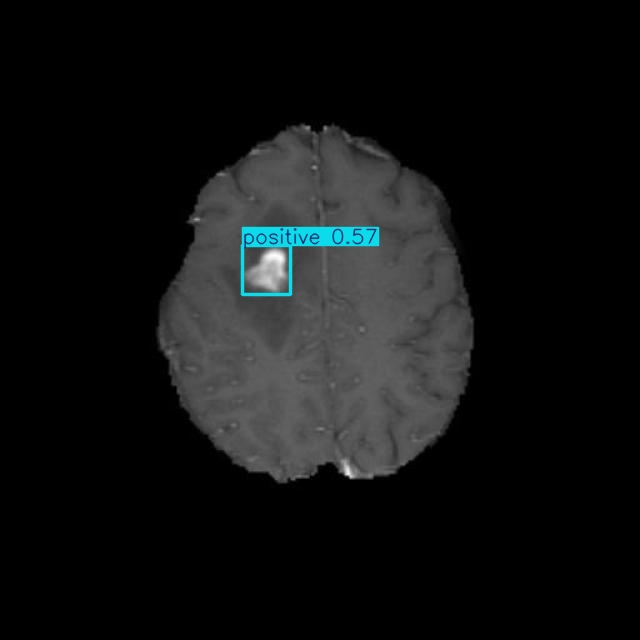

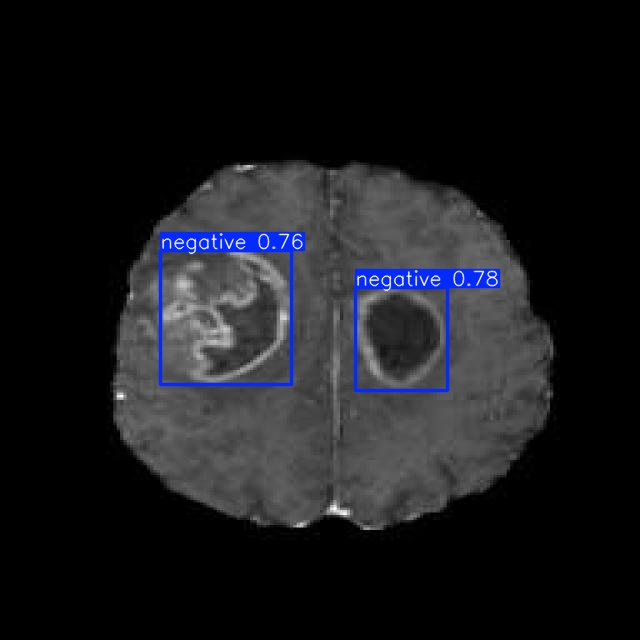

In [17]:
# Prediction Results

import glob
from IPython.display import Image, display

prediction_images = glob.glob("/content/runs/detect/predict/*")

print(f"Found {len(prediction_images)} predicted images.\n")

for image in prediction_images[:3]:
    display(Image(filename=image, width=700))

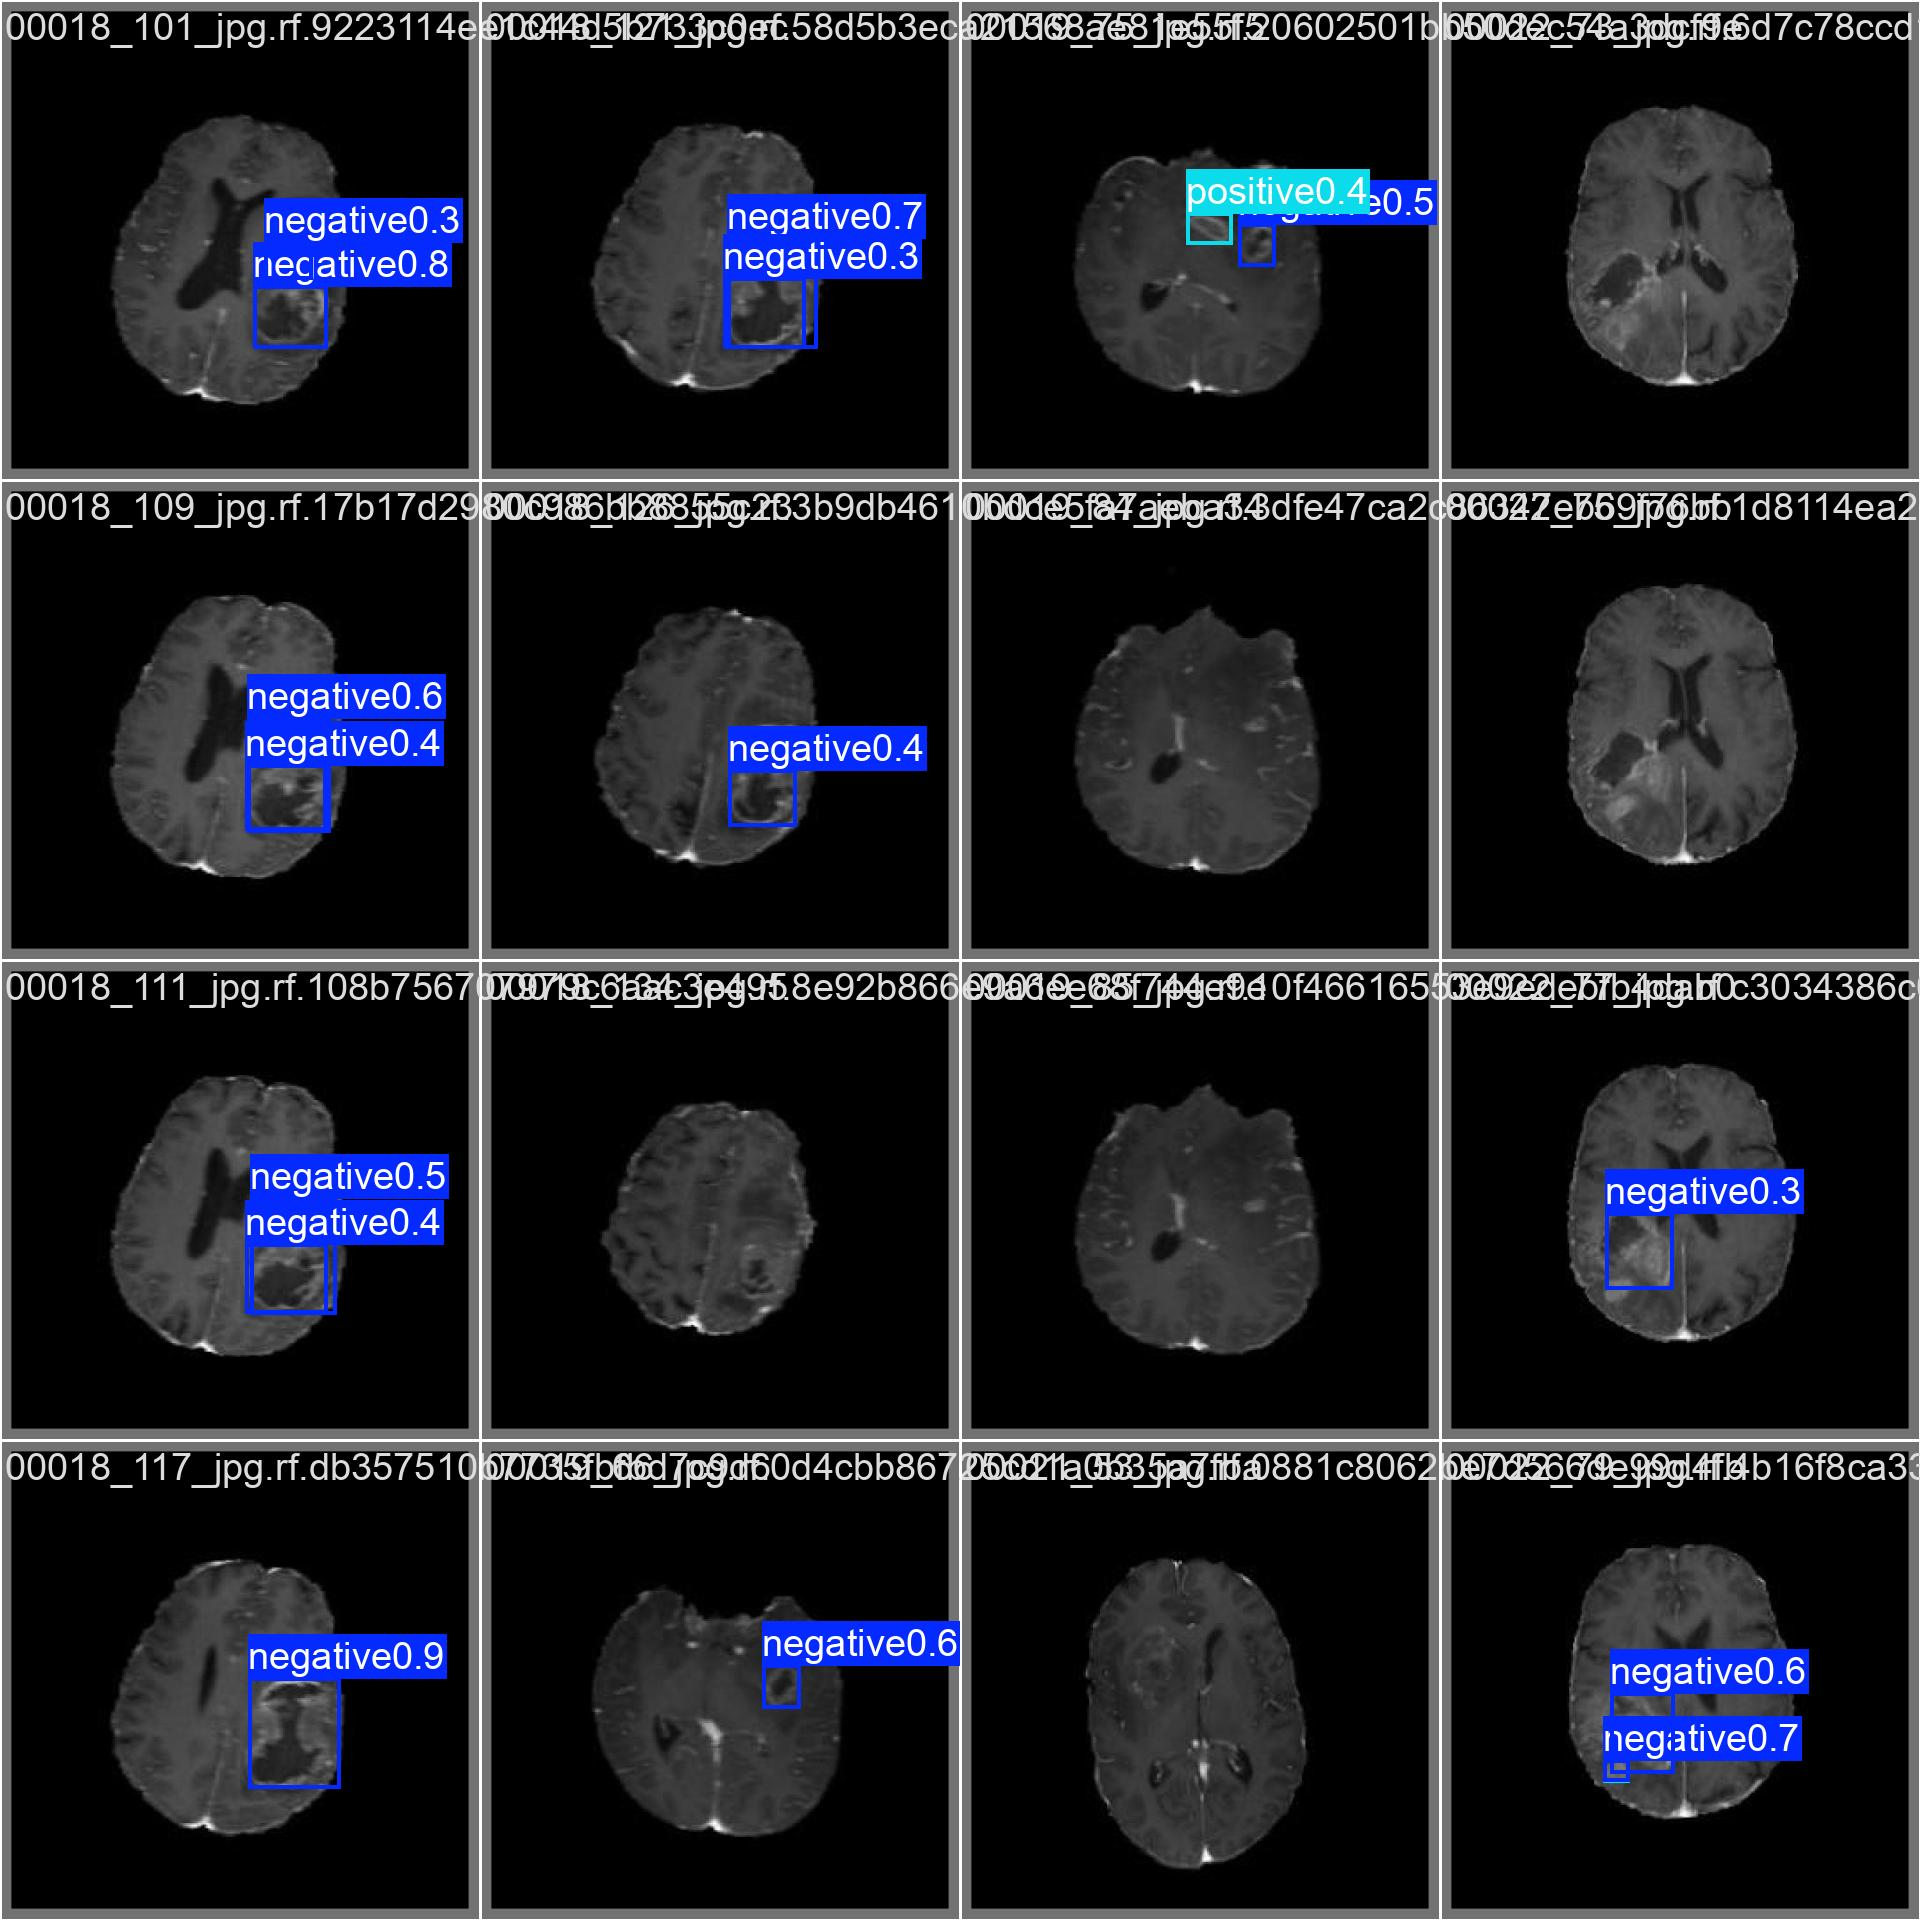

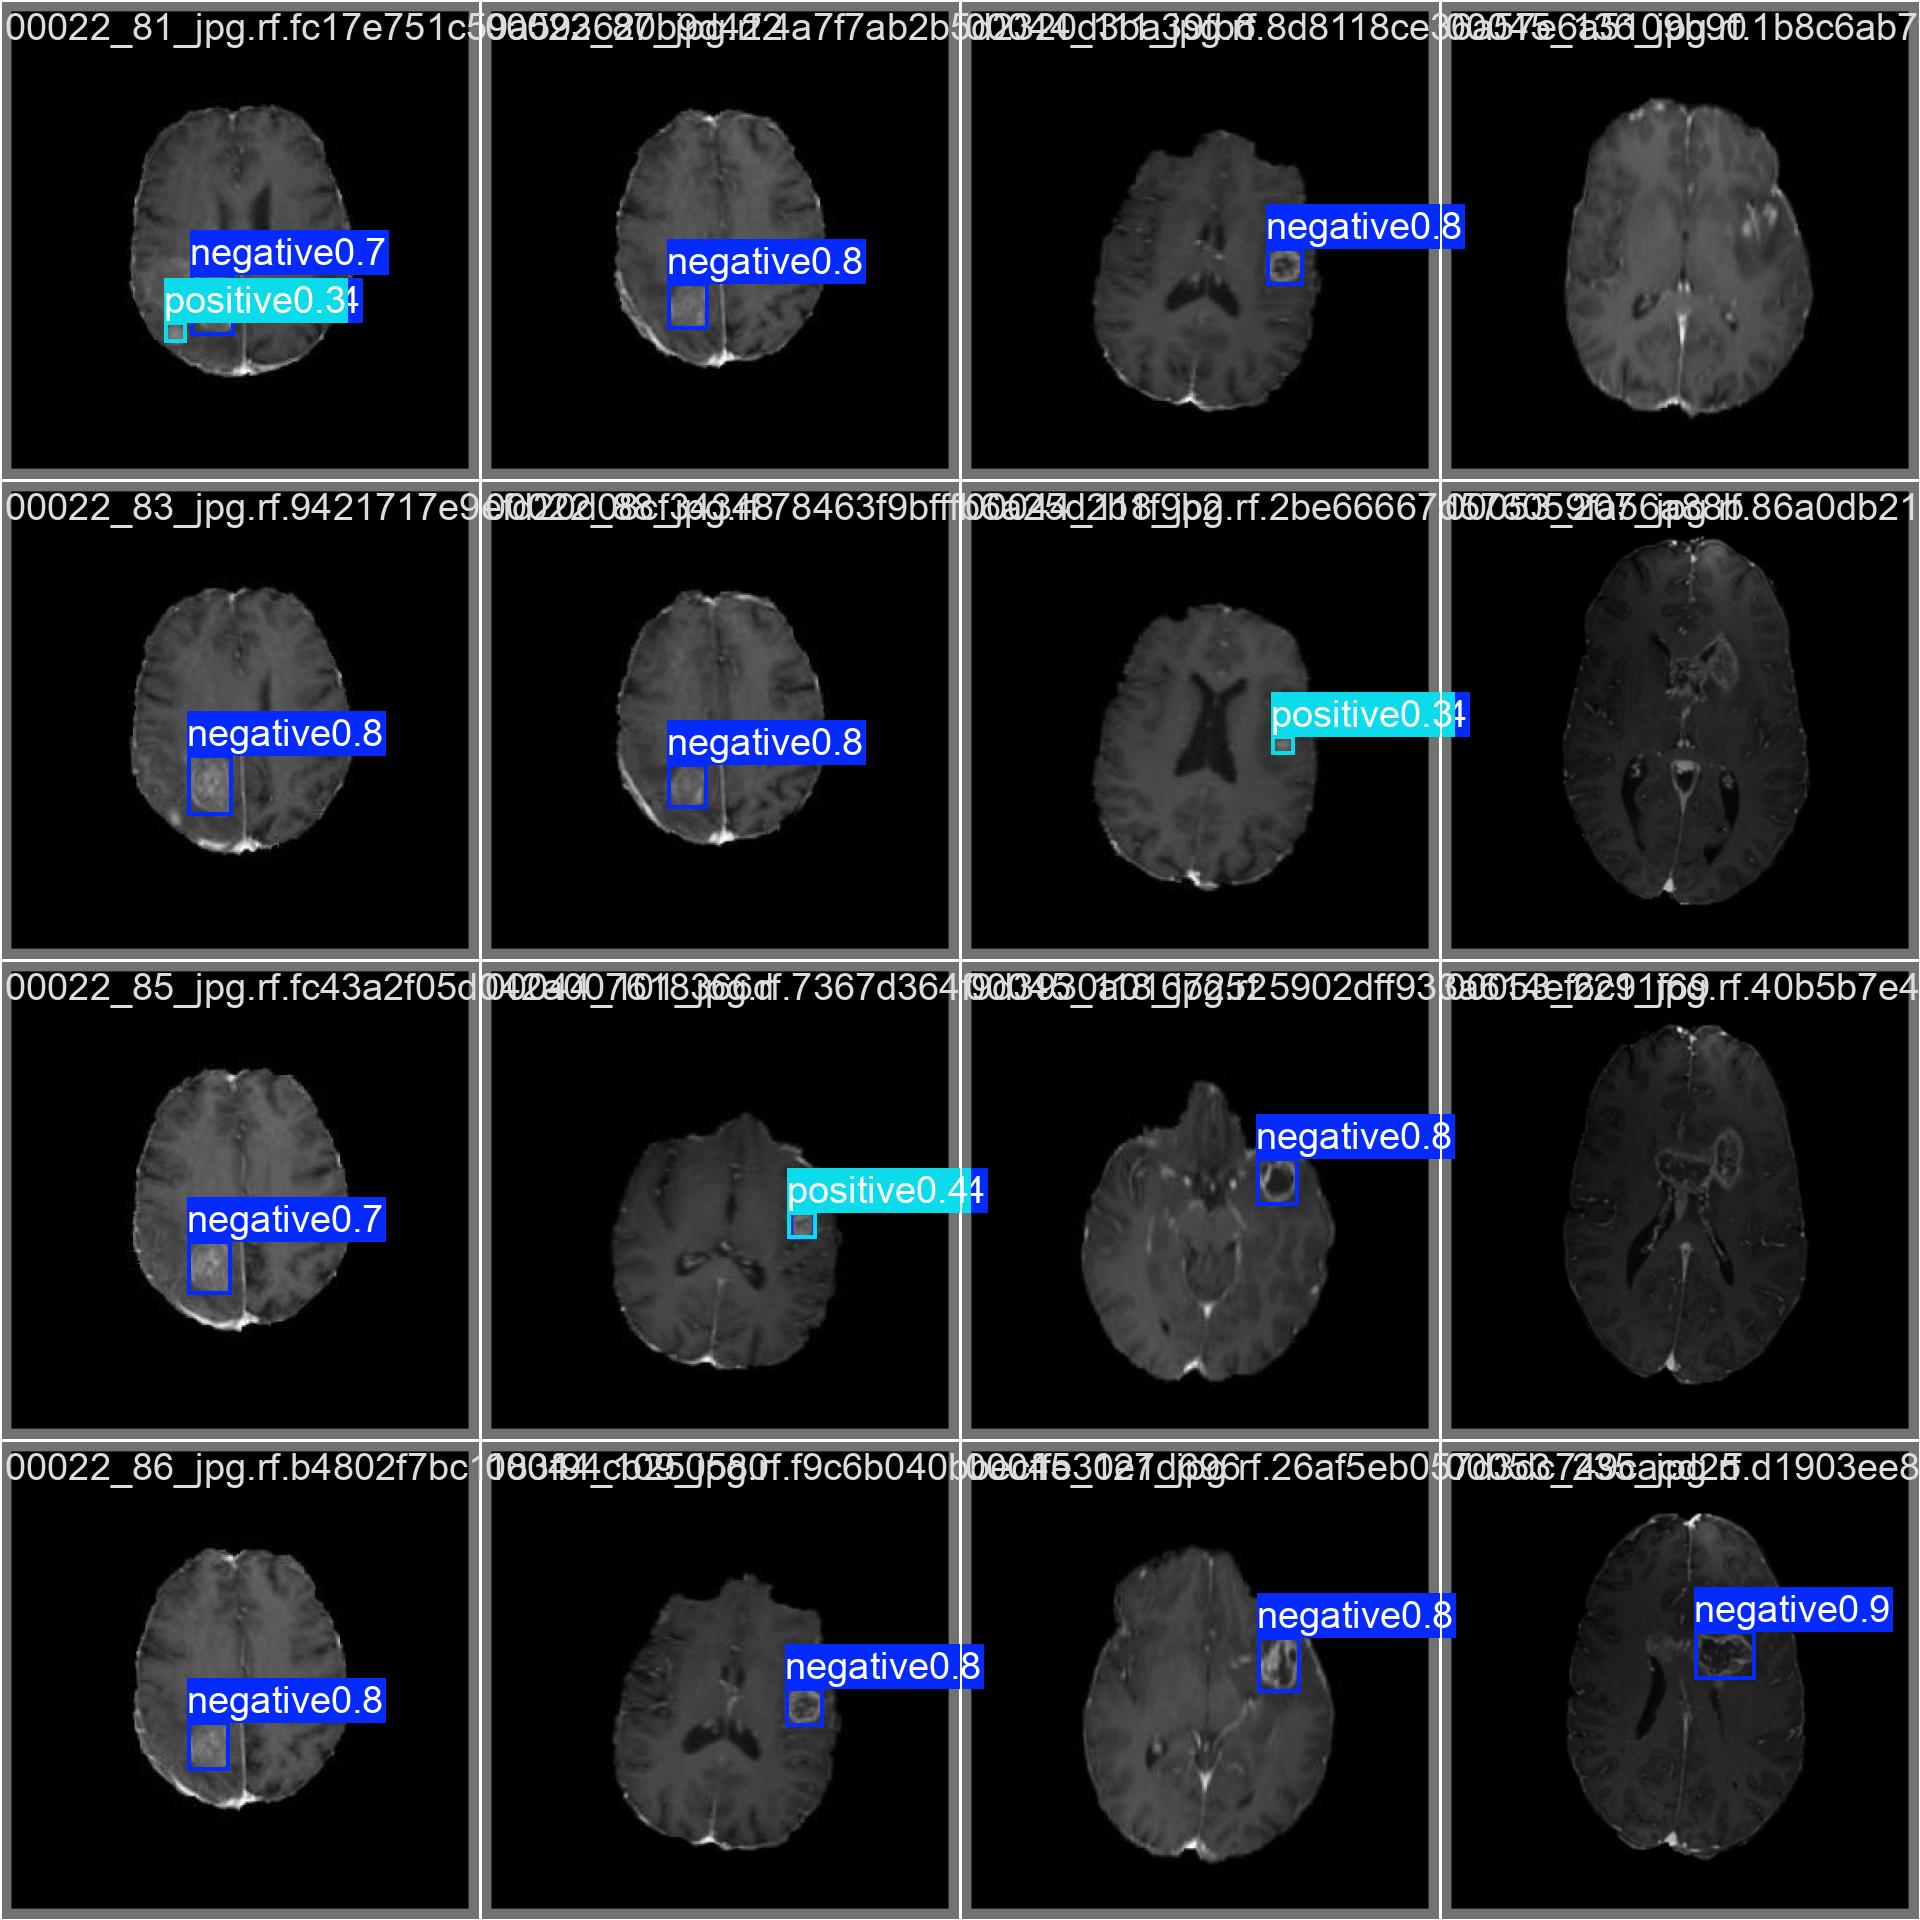

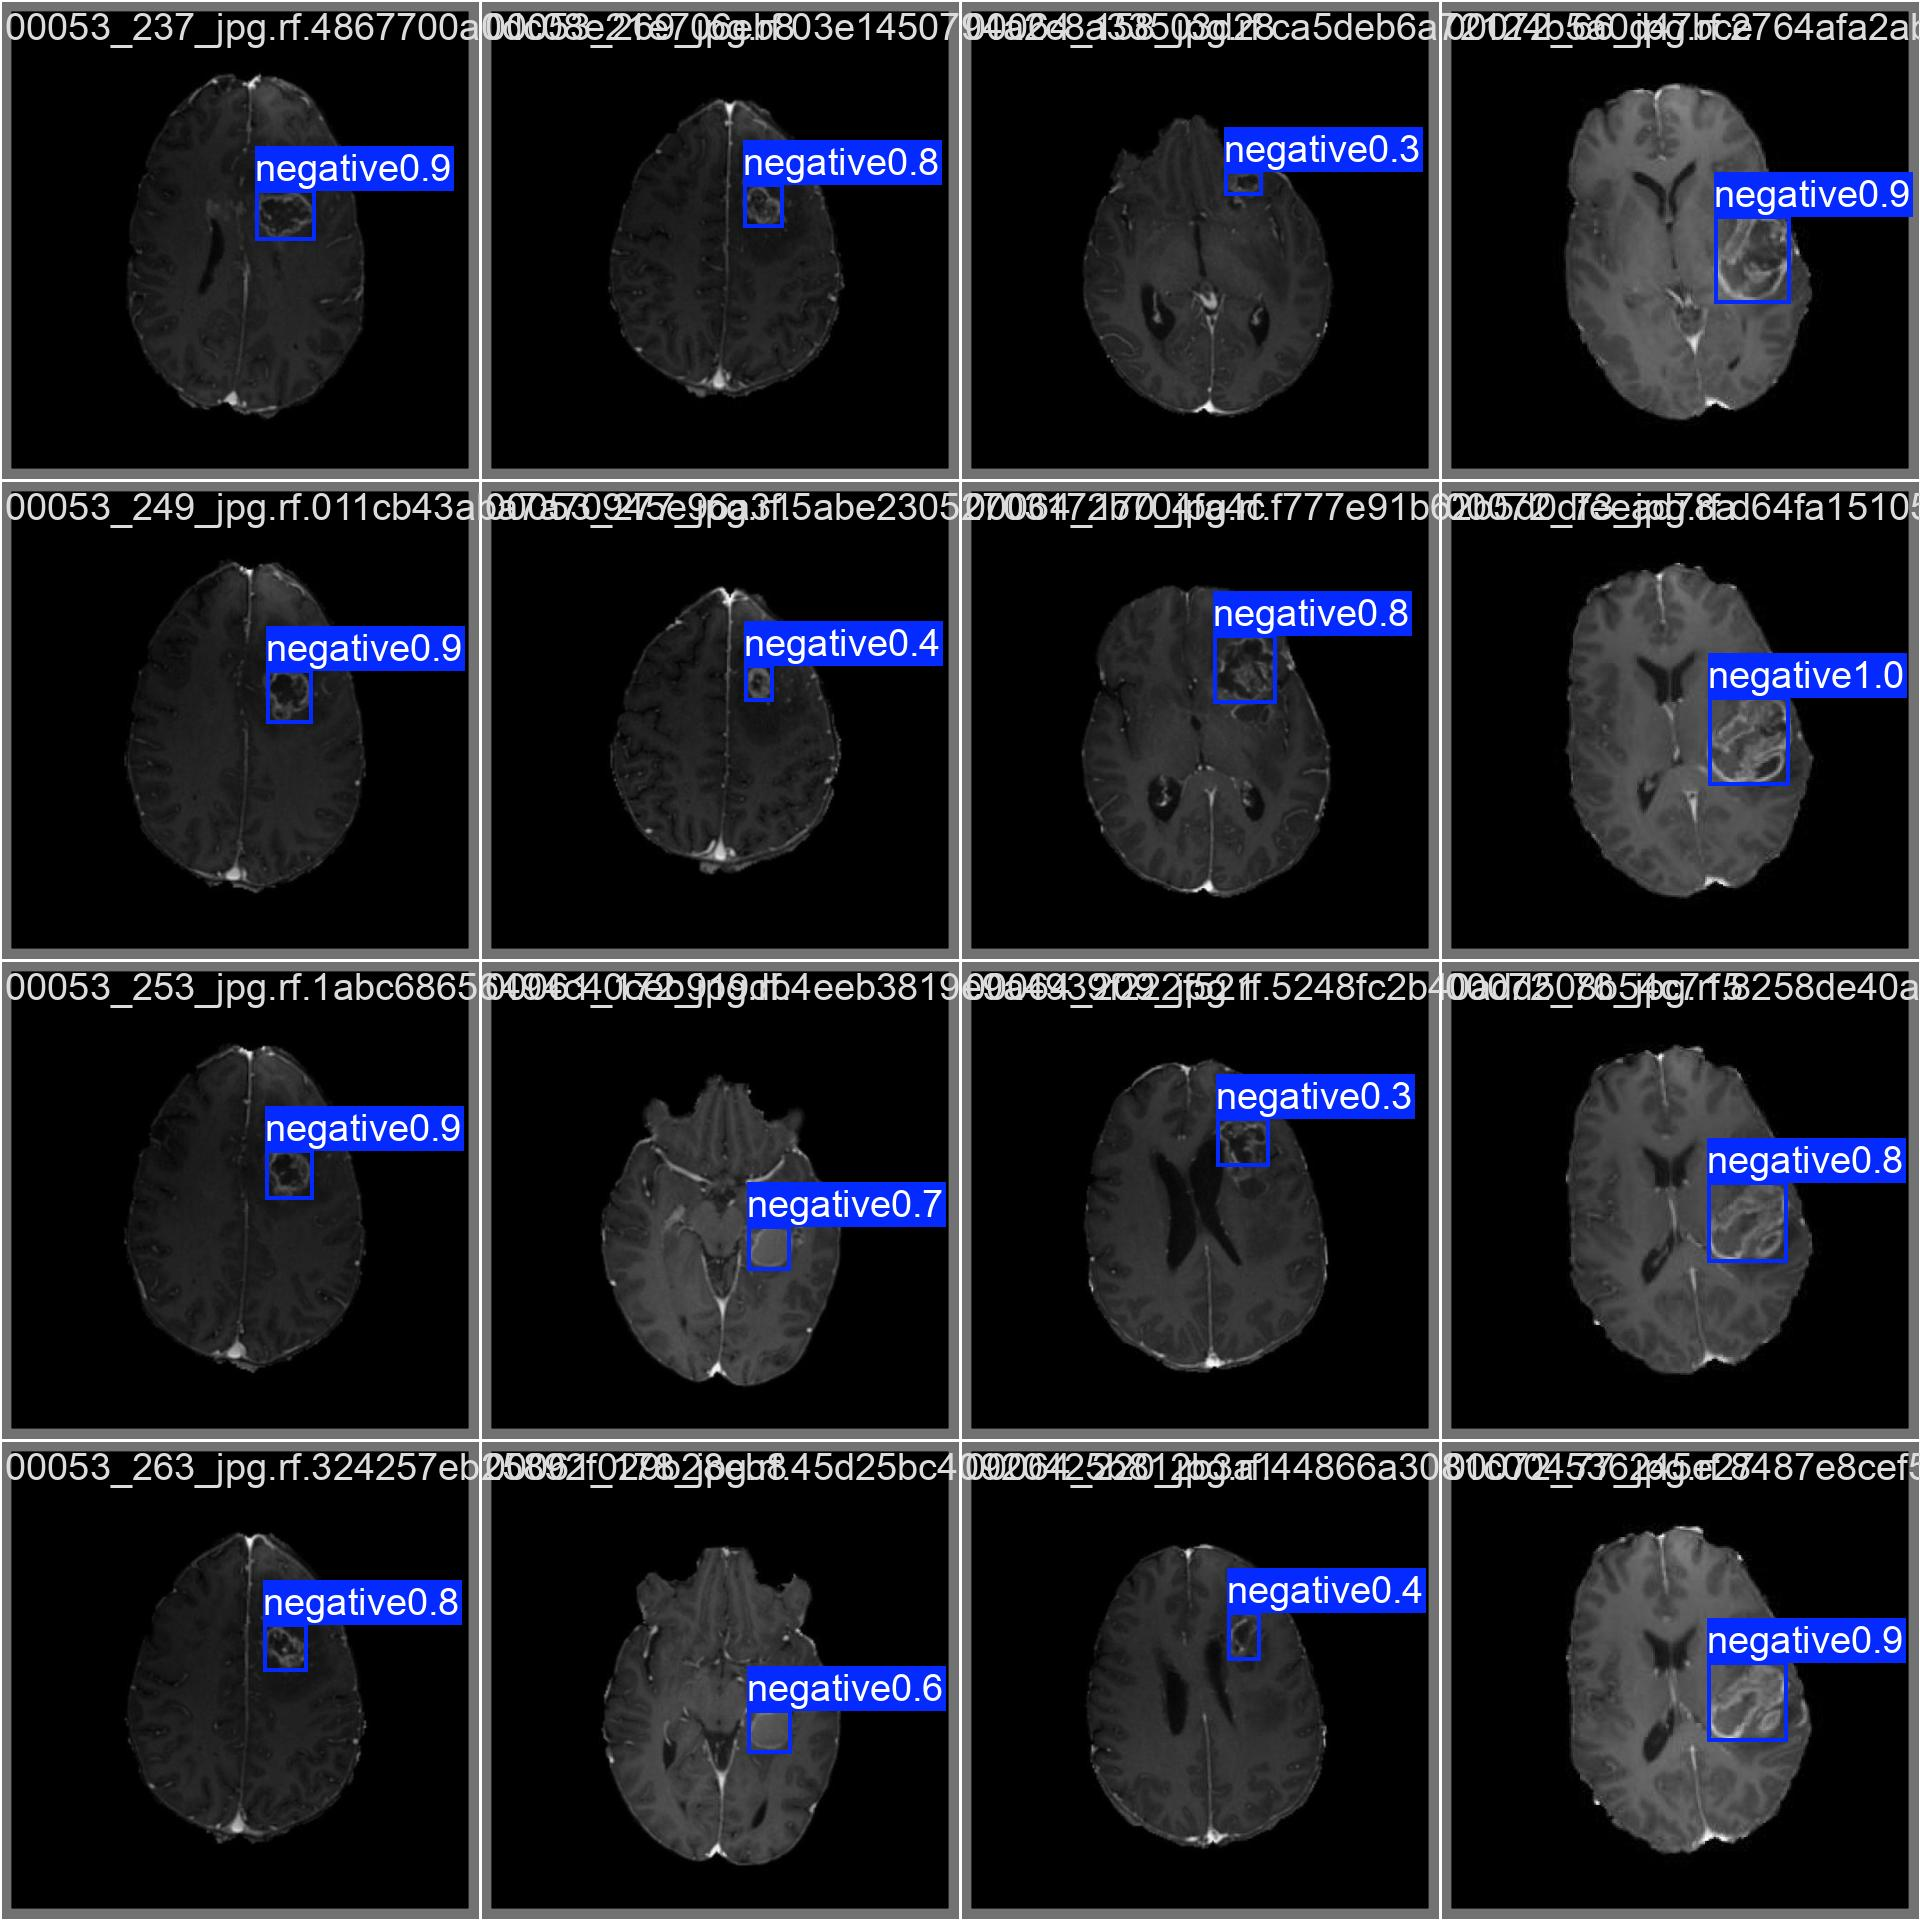

In [18]:
# Validation Images

from IPython.display import Image, display

display(Image("/content/runs/detect/runs/axial_mri_detection-2/val_batch0_pred.jpg", width=700))
display(Image("/content/runs/detect/runs/axial_mri_detection-2/val_batch1_pred.jpg", width=700))
display(Image("/content/runs/detect/runs/axial_mri_detection-2/val_batch2_pred.jpg", width=700))